In [22]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, utils
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
from PIL import Image
import matplotlib.pyplot as plt
import os


#   DCGAN Tuning 

In [1]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3, features_g=64):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x z_dim x 1 x 1
            nn.ConvTranspose2d(z_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),

            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()  # Output range [-1, 1]
        )

    def forward(self, x):
        return self.net(x)


In [3]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3, features_d=64):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # Input: N x img_channels x 64 x 64
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()  # Output: probability
        )

    def forward(self, x):
        return self.net(x)


In [4]:
def check_gradients(model, name="Generator"):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    print(f"[{name}] Gradient Norm: {total_norm:.4f}")
    return total_norm


In [5]:
gen = Generator(z_dim=128, features_g=128).to(device='cpu')
disc = Discriminator(features_d=64).to(device='cpu')


In [6]:
def check_gradients(model, name="Generator"):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** 0.5
    print(f"[{name}] Gradient Norm: {total_norm:.4f}")
    return total_norm


In [7]:
def train_dcgan(config):
    # ===== Setup =====
    z_dim = config['z_dim']
    lr = config['lr']
    batch_size = config['batch_size']
    features_g = config['features_g']
    features_d = config['features_d']
    epochs = config['epochs']
    run_name = config['run_name']
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    save_path = f"experiments/{run_name}"
    os.makedirs(f"{save_path}/images", exist_ok=True)
    os.makedirs(f"{save_path}/checkpoints", exist_ok=True)

    # ===== Transforms and DataLoader =====
    transform = transforms.Compose([
        transforms.Resize(64),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    dataset = datasets.ImageFolder(config['data_path'], transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # ===== Models, Optimizers, Loss =====
    gen = Generator(z_dim=z_dim, features_g=features_g).to(device)
    disc = Discriminator(features_d=features_d).to(device)

    opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))
    criterion = nn.BCELoss()

    fixed_noise = torch.randn(16, z_dim, 1, 1).to(device)
    fid = FrechetInceptionDistance(normalize=True).to(device)
    iscore = InceptionScore(normalize=True).to(device)

    print(f"\n Starting Training: {run_name}\n")
    for epoch in range(epochs):
        gen.train()
        total_loss_g = 0
        total_loss_d = 0

        for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            real = real.to(device)
            cur_batch_size = real.size(0)

            noise = torch.randn(cur_batch_size, z_dim, 1, 1, device=device)
            fake = gen(noise)

            # === Discriminator Training ===
            lossD_real = criterion(disc(real).view(-1), torch.ones(cur_batch_size, device=device))
            lossD_fake = criterion(disc(fake.detach()).view(-1), torch.zeros(cur_batch_size, device=device))
            lossD = lossD_real + lossD_fake

            opt_disc.zero_grad()
            lossD.backward()
            check_gradients(disc, "Discriminator")  # Gradient Norm Check
            opt_disc.step()

            # === Generator Training ===
            output = disc(fake).view(-1)
            lossG = criterion(output, torch.ones_like(output))

            opt_gen.zero_grad()
            lossG.backward()
            check_gradients(gen, "Generator")  # Gradient Norm Check
            opt_gen.step()

            total_loss_g += lossG.item()
            total_loss_d += lossD.item()

        print(f"Epoch {epoch+1} | Loss_D: {total_loss_d:.4f} | Loss_G: {total_loss_g:.4f}")

        # === Save generated preview ===
        with torch.no_grad():
            gen.eval()
            preview = gen(fixed_noise).detach().cpu()
            preview = (preview + 1) / 2
            utils.save_image(preview, f"{save_path}/images/epoch_{epoch+1}.png", nrow=4)

        # === Save checkpoint every 10 epochs ===
        if (epoch + 1) % 10 == 0:
            torch.save(gen.state_dict(), f"{save_path}/checkpoints/gen_epoch{epoch+1}.pth")
            torch.save(disc.state_dict(), f"{save_path}/checkpoints/disc_epoch{epoch+1}.pth")

    # === Final Evaluation ===
    print("\n Calculating FID & Inception Score...")
    gen.eval()
    fake_imgs = []
    real_imgs = []

    with torch.no_grad():
        for real, _ in dataloader:
            real_imgs.append(real)
            noise = torch.randn(real.size(0), z_dim, 1, 1).to(device)
            fake = gen(noise)
            fake_imgs.append(fake.cpu())

    real_imgs = torch.cat(real_imgs)[:500]
    fake_imgs = torch.cat(fake_imgs)[:500]

    fid.update(real_imgs.to(device), real=True)
    fid.update(fake_imgs.to(device), real=False)
    fid_score = fid.compute().item()

    iscore.update(fake_imgs.to(device))
    is_mean, is_std = iscore.compute()

    print(f"\n Finished {run_name}: FID = {fid_score:.2f}, IS = {is_mean:.2f} ± {is_std:.2f}\n")


In [8]:
experiments = [
    {"run_name": "exp1_baseline", "z_dim": 100, "features_g": 64, "features_d": 64, "lr": 2e-4, "batch_size": 64, "epochs": 5, "data_path": "data/final_processed_data/train"},
    {"run_name": "exp2_low_z",    "z_dim": 50,  "features_g": 64, "features_d": 64, "lr": 2e-4, "batch_size": 64, "epochs": 5, "data_path": "data/final_processed_data/train"},
    {"run_name": "exp3_high_lr",  "z_dim": 100, "features_g": 64, "features_d": 64, "lr": 1e-3, "batch_size": 64, "epochs": 5, "data_path": "data/final_processed_data/train"},
    #{"run_name": "exp4_deep_gd",  "z_dim": 100, "features_g": 128, "features_d": 128, "lr": 2e-4, "batch_size": 64, "epochs": 15,"data_path":"data/final_processed_data/train"}
]

for config in experiments:
    train_dcgan(config)


C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)



 Starting Training: exp1_baseline



Epoch 1/5:   0%|          | 0/326 [00:00<?, ?it/s]

[Discriminator] Gradient Norm: 16.6993


Epoch 1/5:   0%|          | 1/326 [00:02<13:28,  2.49s/it]

...

Epoch 5/5: 100%|█████████▉| 325/326 [09:00<00:01,  1.43s/it]

[Generator] Gradient Norm: 2.7751


Epoch 5/5: 100%|██████████| 326/326 [09:00<00:00,  1.66s/it]

[Discriminator] Gradient Norm: 27.4684
[Generator] Gradient Norm: 6.7813
Epoch 5 | Loss_D: 322.0095 | Loss_G: 908.3645



 Calculating FID & Inception Score...

 Finished exp3_high_lr: FID = 161.22, IS = 2.26 ± 0.11



#  Vanishing Gradient check

In [9]:
def get_gradient_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5


In [11]:
epoch = 2
gen_grad_norm = get_gradient_norm(gen)
disc_grad_norm = get_gradient_norm(disc)

print(f"[Epoch {epoch+1}] Generator Gradient Norm: {gen_grad_norm:.4f} | Discriminator Gradient Norm: {disc_grad_norm:.4f}")


[Epoch 3] Generator Gradient Norm: 0.0000 | Discriminator Gradient Norm: 0.0000


In [12]:
epoch = 0
gen_grad_norm = get_gradient_norm(gen)
disc_grad_norm = get_gradient_norm(disc)

print(f"[Epoch {epoch+1}] Generator Gradient Norm: {gen_grad_norm:.4f} | Discriminator Gradient Norm: {disc_grad_norm:.4f}")


[Epoch 1] Generator Gradient Norm: 0.0000 | Discriminator Gradient Norm: 0.0000


In [13]:
epoch = 1
gen_grad_norm = get_gradient_norm(gen)
disc_grad_norm = get_gradient_norm(disc)

print(f"[Epoch {epoch+1}] Generator Gradient Norm: {gen_grad_norm:.4f} | Discriminator Gradient Norm: {disc_grad_norm:.4f}")


[Epoch 2] Generator Gradient Norm: 0.0000 | Discriminator Gradient Norm: 0.0000


#  Mode collapse

In [19]:
import os

run_name = "dcgan_test_run"  # customize this per experiment
save_path = f"experiments2/{run_name}"
os.makedirs(f"{save_path}/images", exist_ok=True)
os.makedirs(f"{save_path}/checkpoints", exist_ok=True)

In [20]:
z_dim=128
fixed_noise = torch.randn(64, z_dim, 1, 1).to(device='cpu')
with torch.no_grad():
    preview = gen(fixed_noise).detach().cpu()
    preview = (preview + 1) / 2
    utils.save_image(preview, f"{save_path}/images/epoch_{epoch+1}.png", nrow=4)


In [23]:
run_name = "dcgan_test_run"
img_dir = f"experiments2/{run_name}/images"

# Get image file names like epoch_1.png, epoch_10.png
image_files = sorted([f for f in os.listdir(img_dir) if f.endswith(".png")])
print("Available Images:", image_files)


Available Images: ['epoch_2.png']


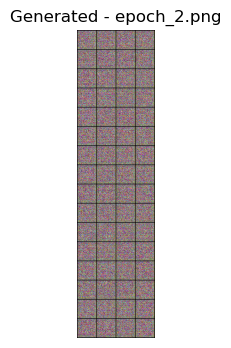

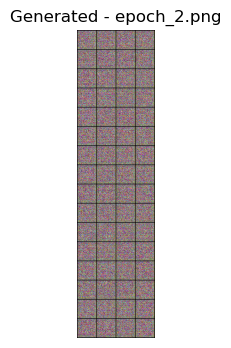

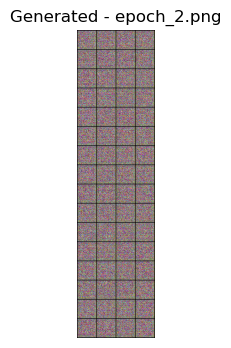

In [24]:
# Display 3 example images: first, middle, last
examples = [image_files[0], image_files[len(image_files)//2], image_files[-1]]

for fname in examples:
    img_path = os.path.join(img_dir, fname)
    img = Image.open(img_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"Generated - {fname}")
    plt.axis("off")
    plt.show()


#   Conclusion 

Based on visual inspection of generated images across multiple epochs, there is no evidence of mode collapse. The generator is producing diverse outputs in response to different noise vectors, even though the overall image quality remains poor. This suggests the generator is undertrained rather than collapsing to a limited set of outputs. Further training and tuning are needed to improve realism, but mode diversity is currently preserved.